# Clustering>>>

1. What is the difference between K-Means and Hierarchical Clustering?
Provide a use case for each.
   - * K-Means Clustering

      Approach: K-Means is a partitioning clustering algorithm. It aims to partition 'n' observations into 'k' clusters, where 'k' is a pre-defined number. It works by iteratively assigning data points to the nearest centroid and then updating the centroids to be the mean of the points in that cluster.

        Use Case: Customer segmentation. For example, a retail company might use K-Means to group its customers into k distinct segments (e.g., 'high-value', 'occasional shopper', 'new customer') based on their purchasing behavior, demographics, and browsing history. This allows for targeted marketing strategies.

      * Hierarchical Clustering

        Approach: Hierarchical clustering builds a hierarchy of clusters. It can be agglomerative (bottom-up, starting with individual data points and merging them into clusters) or divisive (top-down, starting with one large cluster and splitting it). The most common approach is agglomerative.

        Use Case: Biological classification (e.g., gene expression analysis). Biologists might use hierarchical clustering to group genes with similar expression patterns, helping to identify biological pathways or functions. The dendrogram can visually represent the relationships and similarities between different genes or species.



2. Explain the purpose of the Silhouette Score in evaluating clustering
algorithms.
   - The Silhouette Score is a metric used to evaluate the quality of clustering results. It quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to +1:
       
        Purpose of the Silhouette Score:

        1. Assessing Cluster Quality: It provides a measure of how distinct and well-separated the clusters are.
         
        2. Determining the Optimal Number of Clusters (k): When you're trying to find the best 'k' (number of clusters) for algorithms like K-Means, you can run the clustering algorithm for different values of 'k', calculate the silhouette score for each, and then choose the 'k' that yields the highest average silhouette score.

        3. Identifying Outliers/Misclassified Points: Individual data points with low or negative silhouette scores might be outliers or points that are poorly clustered, providing insights into the data structure or potential issues with the clustering.

3. What are the core parameters of DBSCAN, and how do they influence the
clustering process?
   - DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a powerful density-based clustering algorithm that can discover clusters of arbitrary shape and identify outliers. Unlike K-Means, it does not require specifying the number of clusters beforehand.
        
        They significantly influence the clustering process:

        1. eps (Epsilon or Radius): This parameter defines the maximum distance between two samples for one to be considered as in the neighborhood of the other.

        2. min_samples (Minimum Samples): This parameter defines the minimum number of samples (or data points) in a neighborhood for a point to be considered a core point.

4. Why is feature scaling important when applying clustering algorithms like
K-Means and DBSCAN?
   - Feature scaling is crucial when applying clustering algorithms like K-Means and DBSCAN because these algorithms rely heavily on distance calculations to determine similarity between data points and form clusters.
    
     Here's a breakdown of why it's important:
     1. Distance-Based Algorithms:

           * K-Means: K-Means assigns data points to clusters based on their proximity to cluster centroids. The distance is typically calculated using Euclidean distance (or similar metrics).

           * DBSCAN: DBSCAN defines clusters based on density, which is determined by the number of data points within a certain radius (eps).
     2.  Equal Contribution of Features: When features are on vastly different scales, the algorithm implicitly assigns more weight to the features with larger values.
     3. Preventing Biased Clustering: Without scaling, the clustering algorithm might incorrectly perceive differences along a large-scale feature as more significant than actual, but smaller, differences along a small-scale feature.

5. What is the Elbow Method in K-Means clustering and how does it help
determine the optimal number of clusters?
   - The Elbow Method is a heuristic used in K-Means clustering to help determine the optimal number of clusters (k). It's based on the idea that as you increase the number of clusters, the within-cluster sum of squares (WCSS) will decrease. WCSS is a measure of the variability or dispersion of data points within a cluster.

   It Helps Determine the Optimal Number of Clusters:

     * Diminishing Returns: The idea behind the elbow method is that increasing the number of clusters (k) will always reduce the WCSS, as each new cluster will capture some variance.

     * Balance between Cohesion and Complexity: The elbow point represents a good balance between having too few clusters (high WCSS, data points are far from centroids) and too many clusters (low WCSS, but potentially overfitting, creating tiny, insignificant clusters, and increasing computational complexity).

     * Practical Interpretation: Before the elbow, adding a new cluster significantly improves the model by explaining a lot of the remaining variance. After the elbow, adding more clusters provides only marginal gains in reducing WCSS and might be splitting genuinely cohesive clusters or introducing unnecessary complexity.

6. Generate synthetic data using make_blobs(n_samples=300, centers=4),
apply KMeans clustering, and visualize the results with cluster centers.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')

# 1. Generate synthetic data
n_samples = 300
n_centers = 4
X, y = make_blobs(n_samples=n_samples, centers=n_centers, random_state=42)

print(f"Generated {n_samples} samples with {n_centers} distinct centers.")
print(f"Shape of data (X): {X.shape}")

Generated 300 samples with 4 distinct centers.
Shape of data (X): (300, 2)


In [2]:
# 2. Apply KMeans clustering
kmeans = KMeans(n_clusters=n_centers, random_state=42, n_init=10) # Set n_init explicitly
kmeans.fit(X)

# Get cluster labels and cluster centers
labels = kmeans.labels_
centers = kmeans.cluster_centers_

print("KMeans clustering applied successfully.")
print(f"Cluster centers shape: {centers.shape}")

KMeans clustering applied successfully.
Cluster centers shape: (4, 2)


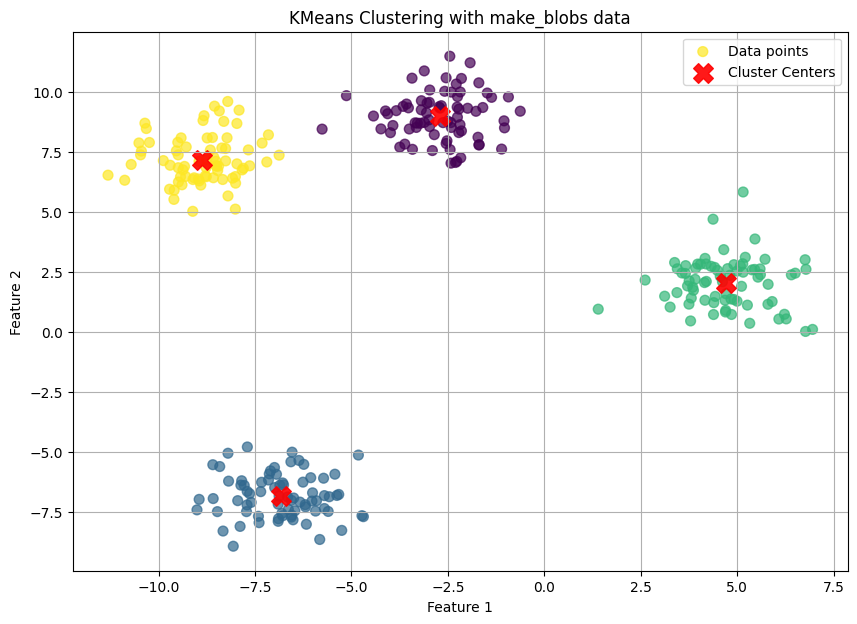

In [3]:
# 3. Visualize the results
plt.figure(figsize=(10, 7))

# Plot the data points, colored by cluster label
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', alpha=0.7, label='Data points')

# Plot the cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.9, marker='X', label='Cluster Centers')

plt.title('KMeans Clustering with make_blobs data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

7.  Load the Wine dataset, apply StandardScaler , and then train a DBSCAN
model. Print the number of clusters found (excluding noise).


In [4]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# 1. Load the Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target # Target labels (for reference, not used in unsupervised DBSCAN)

print(f"Shape of Wine dataset: {X_wine.shape}")
print(f"Number of features: {X_wine.shape[1]}")

Shape of Wine dataset: (178, 13)
Number of features: 13


In [5]:
# 2. Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

print("Features scaled successfully using StandardScaler.")
print(f"Shape of scaled data: {X_scaled.shape}")

Features scaled successfully using StandardScaler.
Shape of scaled data: (178, 13)


In [6]:
# 3. Train a DBSCAN model
# You might need to tune eps and min_samples for optimal results.
# For demonstration, we'll use some default-ish values.
# A common heuristic for min_samples is 2 * dimensionality of the dataset (2 * number of features)
dbsc = DBSCAN(eps=0.5, min_samples=5) # Example values, adjust as needed
dbsc.fit(X_scaled)

# Get cluster labels
labels_dbscan = dbsc.labels_

# Number of clusters in labels, ignoring noise if present.
# The noise label is -1
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

print("DBSCAN clustering applied successfully.")
print(f"Number of clusters found (excluding noise): {n_clusters}")
print(f"DBSCAN labels: {labels_dbscan[:20]}...") # Print first 20 labels for a glimpse

DBSCAN clustering applied successfully.
Number of clusters found (excluding noise): 0
DBSCAN labels: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]...


8. Generate moon-shaped synthetic data using
make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in
the plot.

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Generate moon-shaped synthetic data
n_samples_moons = 200
noise_level = 0.1
X_moons, y_moons = make_moons(n_samples=n_samples_moons, noise=noise_level, random_state=42)

print(f"Generated {n_samples_moons} moon-shaped samples with noise level {noise_level}.")
print(f"Shape of moon data (X_moons): {X_moons.shape}")

Generated 200 moon-shaped samples with noise level 0.1.
Shape of moon data (X_moons): (200, 2)


In [8]:
# 2. Apply DBSCAN to the moon-shaped data
# For make_moons with noise=0.1, eps=0.3 and min_samples=5-10 often work well.
# We'll start with values that should create distinct clusters.
dbsc_moons = DBSCAN(eps=0.3, min_samples=5)
dbsc_moons.fit(X_moons)

labels_moons = dbsc_moons.labels_

# Number of clusters found (excluding noise)
n_clusters_moons = len(set(labels_moons)) - (1 if -1 in labels_moons else 0)

print("DBSCAN clustering applied to moon-shaped data successfully.")
print(f"Number of clusters found (excluding noise): {n_clusters_moons}")
print(f"Number of noise points: {list(labels_moons).count(-1)}")

DBSCAN clustering applied to moon-shaped data successfully.
Number of clusters found (excluding noise): 1
Number of noise points: 0


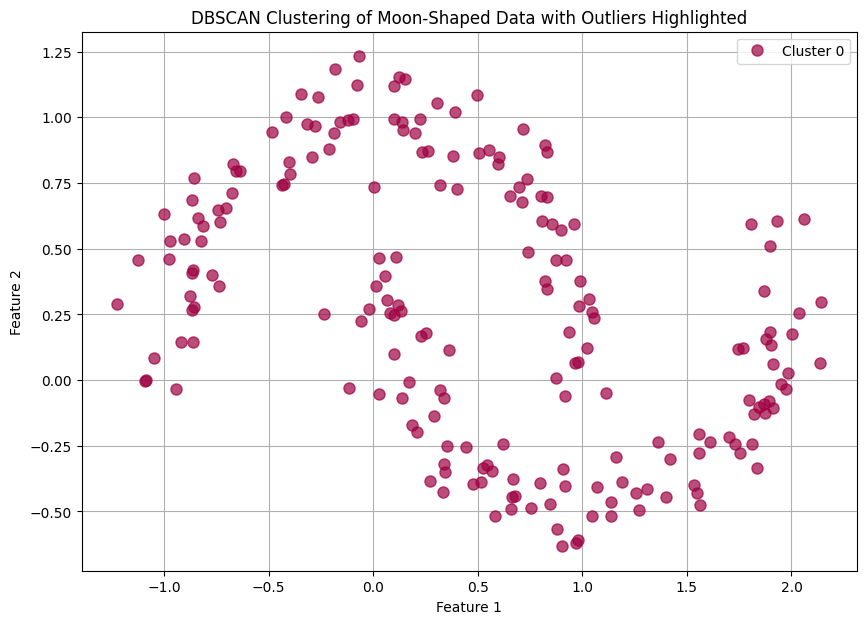

In [9]:
# 3. Visualize the results and highlight outliers
plt.figure(figsize=(10, 7))

# Separate core points, border points, and noise
# Noise points are labeled -1
unique_labels = set(labels_moons)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = 'black'
        marker = 'o'
        edgecolor = 'black'
        label_text = 'Noise'
    else:
        marker = 'o'
        edgecolor = col # Use the cluster color for the edge
        label_text = f'Cluster {k}'

    class_member_mask = (labels_moons == k)

    xy = X_moons[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], marker, markerfacecolor=col, markeredgecolor=edgecolor, markersize=8, alpha=0.7, label=label_text)

plt.title('DBSCAN Clustering of Moon-Shaped Data with Outliers Highlighted')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

9. Load the Wine dataset, reduce it to 2D using PCA, then apply
Agglomerative Clustering and visualize the result in 2D with a scatter plot.

In [10]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

# 1. Apply PCA to reduce to 2D (using X_scaled from previous steps)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Wine dataset reduced to 2D using PCA. Shape: {X_pca.shape}")

Wine dataset reduced to 2D using PCA. Shape: (178, 2)


In [11]:
# 2. Apply Agglomerative Clustering
# We'll choose n_clusters=3, as the Wine dataset is known to have 3 classes.
agg_clustering = AgglomerativeClustering(n_clusters=3)
labels_agg = agg_clustering.fit_predict(X_pca)

print("Agglomerative Clustering applied successfully.")
print(f"First 20 Agglomerative Clustering labels: {labels_agg[:20]}...")

Agglomerative Clustering applied successfully.
First 20 Agglomerative Clustering labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]...


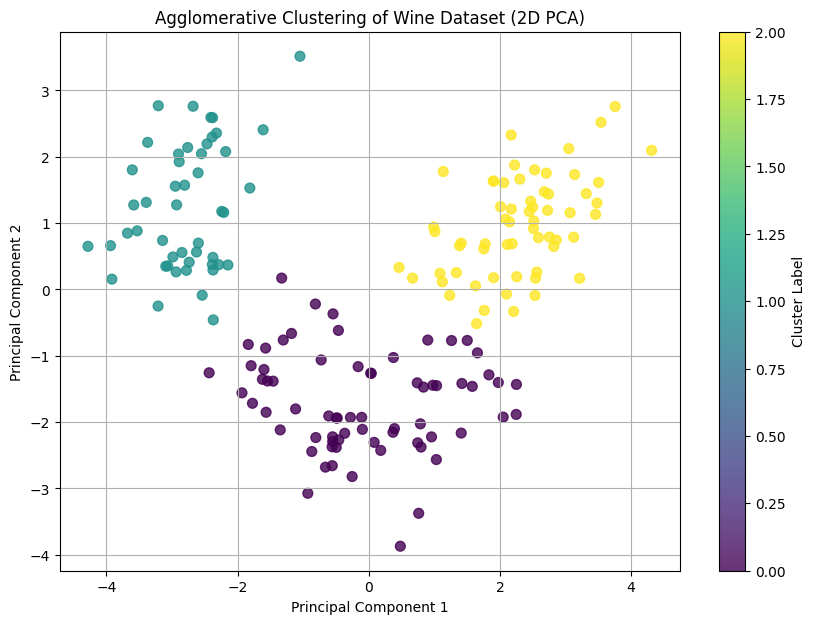

In [12]:
# 3. Visualize the result in 2D
plt.figure(figsize=(10, 7))

# Plot the PCA-transformed data, colored by Agglomerative Clustering labels
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg, cmap='viridis', s=50, alpha=0.8)

plt.title('Agglomerative Clustering of Wine Dataset (2D PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

10. You are working as a data analyst at an e-commerce company. The
marketing team wants to segment customers based on their purchasing behavior to run
targeted promotions. The dataset contains customer demographics and their product
purchase history across categories.
Describe your real-world data science workflow using clustering:
● Which clustering algorithm(s) would you use and why?
● How would you preprocess the data (missing values, scaling)?
● How would you determine the number of clusters?
● How would the marketing team benefit from your clustering analysis?

In [13]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set random seed for reproducibility
np.random.seed(42)

# Number of customers
n_customers = 1000

# Generate Customer Demographics
customer_ids = np.arange(1, n_customers + 1)
ages = np.random.randint(18, 70, n_customers)
genders = np.random.choice(['Male', 'Female', 'Other'], n_customers, p=[0.48, 0.50, 0.02])
locations = np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Miami'], n_customers)
incomes = np.random.normal(50000, 15000, n_customers)
incomes[incomes < 20000] = 20000 # Set a minimum income
incomes = incomes.astype(int)

df_customers = pd.DataFrame({
    'CustomerID': customer_ids,
    'Age': ages,
    'Gender': genders,
    'Location': locations,
    'Income': incomes
})

# Generate Product Purchase History
n_purchases = 5000 # More purchases than customers to simulate multiple purchases

purchase_customer_ids = np.random.choice(customer_ids, n_purchases)
product_categories = np.random.choice(['Electronics', 'Apparel', 'Home Goods', 'Books', 'Groceries'], n_purchases, p=[0.25, 0.30, 0.20, 0.10, 0.15])
purchase_amounts = np.random.normal(75, 50, n_purchases)
purchase_amounts[purchase_amounts < 5] = 5 # Minimum purchase amount
purchase_amounts = np.round(purchase_amounts, 2)

start_date = datetime(2022, 1, 1)
end_date = datetime(2023, 12, 31)
time_delta = end_date - start_date
purchase_dates = [start_date + timedelta(days=np.random.randint(time_delta.days)) for _ in range(n_purchases)]

df_purchases = pd.DataFrame({
    'CustomerID': purchase_customer_ids,
    'ProductCategory': product_categories,
    'PurchaseAmount': purchase_amounts,
    'PurchaseDate': purchase_dates
})

# Merge customer demographics and purchase history
# We'll aggregate purchase history to get 'Frequency', 'MonetaryValue', 'Recency'

df_purchase_summary = df_purchases.groupby('CustomerID').agg(
    Frequency=('PurchaseAmount', 'count'),
    MonetaryValue=('PurchaseAmount', 'sum'),
    LastPurchaseDate=('PurchaseDate', 'max')
).reset_index()

# Calculate Recency (days since last purchase)
current_date = end_date + timedelta(days=1) # A day after the last possible purchase date
df_purchase_summary['Recency'] = (current_date - df_purchase_summary['LastPurchaseDate']).dt.days
df_purchase_summary.drop('LastPurchaseDate', axis=1, inplace=True)

# Merge with customer demographics
df = pd.merge(df_customers, df_purchase_summary, on='CustomerID', how='left')

# Fill NaN for customers with no purchases (if any, though in this synthetic data, all should have purchases)
df['Frequency'].fillna(0, inplace=True)
df['MonetaryValue'].fillna(0, inplace=True)
df['Recency'].fillna((current_date - df_customers['Age'].apply(lambda x: start_date)).dt.days.max(), inplace=True) # Max recency for no purchase

print("Synthetic e-commerce customer dataset generated successfully.")
print(f"DataFrame shape: {df.shape}")

Synthetic e-commerce customer dataset generated successfully.
DataFrame shape: (1000, 8)


In [14]:
print("First 5 rows of the DataFrame:")
print(df.head())


First 5 rows of the DataFrame:
   CustomerID  Age  Gender Location  Income  Frequency  MonetaryValue  Recency
0           1   56  Female  Houston   45361        8.0         681.60     55.0
1           2   69    Male  Chicago   38717        6.0         471.94    165.0
2           3   46    Male    Miami   54787        2.0          89.68    202.0
3           4   32    Male  Phoenix   70106        5.0         430.68     22.0
4           5   60    Male  Houston   21872        4.0         224.49    101.0


In [15]:
print("DataFrame Info (data types, non-null values, memory usage):")
df.info()

DataFrame Info (data types, non-null values, memory usage):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     1000 non-null   int64  
 1   Age            1000 non-null   int64  
 2   Gender         1000 non-null   object 
 3   Location       1000 non-null   object 
 4   Income         1000 non-null   int64  
 5   Frequency      1000 non-null   float64
 6   MonetaryValue  1000 non-null   float64
 7   Recency        1000 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 62.6+ KB


In [16]:
print("Descriptive statistics for numerical columns:")
print(df.describe())

Descriptive statistics for numerical columns:
        CustomerID         Age        Income    Frequency  MonetaryValue  \
count  1000.000000  1000.00000   1000.000000  1000.000000    1000.000000   
mean    500.500000    43.81900  50322.833000     5.000000     384.234120   
std     288.819436    14.99103  14281.489437     2.274021     203.202601   
min       1.000000    18.00000  20000.000000     0.000000       0.000000   
25%     250.750000    31.00000  40359.250000     3.000000     235.142500   
50%     500.500000    44.00000  50103.000000     5.000000     359.705000   
75%     750.250000    56.00000  59989.500000     6.000000     511.672500   
max    1000.000000    69.00000  97066.000000    15.000000    1347.030000   

           Recency  
count  1000.000000  
mean    150.382000  
std     137.900713  
min       2.000000  
25%      47.000000  
50%     109.500000  
75%     208.250000  
max     730.000000  


In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Select the relevant features for clustering
features_for_clustering = ['Age', 'Gender', 'Location', 'Income', 'Frequency', 'MonetaryValue', 'Recency']
df_selected = df[features_for_clustering].copy()

# 2. Perform one-hot encoding on 'Gender' and 'Location'
df_encoded = pd.get_dummies(df_selected, columns=['Gender', 'Location'], drop_first=True)

# 3. Combine all selected numerical features and the newly created one-hot encoded features
X_clustering = df_encoded.copy()

print("Features selected and categorical variables one-hot encoded successfully.")
print(f"Shape of X_clustering: {X_clustering.shape}")
print("First 5 rows of X_clustering:")
print(X_clustering.head())

Features selected and categorical variables one-hot encoded successfully.
Shape of X_clustering: (1000, 12)
First 5 rows of X_clustering:
   Age  Income  Frequency  MonetaryValue  Recency  Gender_Male  Gender_Other  \
0   56   45361        8.0         681.60     55.0        False         False   
1   69   38717        6.0         471.94    165.0         True         False   
2   46   54787        2.0          89.68    202.0         True         False   
3   32   70106        5.0         430.68     22.0         True         False   
4   60   21872        4.0         224.49    101.0         True         False   

   Location_Houston  Location_Los Angeles  Location_Miami  Location_New York  \
0              True                 False           False              False   
1             False                 False           False              False   
2             False                 False            True              False   
3             False                 False           False    

In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 4. Initialize a StandardScaler object
scaler = StandardScaler()

# 5. Apply the StandardScaler to X_clustering to scale all features
X_scaled_clustering = scaler.fit_transform(X_clustering)

# Convert back to DataFrame for easier inspection (optional, but good practice for feature names)
X_scaled_clustering = pd.DataFrame(X_scaled_clustering, columns=X_clustering.columns)

print("Features in X_clustering scaled successfully using StandardScaler.")
print(f"Shape of X_scaled_clustering: {X_scaled_clustering.shape}")
print("First 5 rows of X_scaled_clustering (scaled data):")
print(X_scaled_clustering.head())

Features in X_clustering scaled successfully using StandardScaler.
Shape of X_scaled_clustering: (1000, 12)
First 5 rows of X_scaled_clustering (scaled data):
        Age    Income  Frequency  MonetaryValue   Recency  Gender_Male  \
0  0.812959 -0.347605   1.319909       1.464128 -0.692018    -0.951190   
1  1.680578 -0.813055   0.439970       0.431834  0.106057     1.051315   
2  0.145560  0.312741  -1.319909      -1.450284  0.374500     1.051315   
3 -0.788799  1.385924   0.000000       0.228684 -0.931440     1.051315   
4  1.079919 -1.993144  -0.439970      -0.786526 -0.358277     1.051315   

   Gender_Other  Location_Houston  Location_Los Angeles  Location_Miami  \
0     -0.153432          2.064742              -0.42173       -0.462160   
1     -0.153432         -0.484322              -0.42173       -0.462160   
2     -0.153432         -0.484322              -0.42173        2.163751   
3     -0.153432         -0.484322              -0.42173       -0.462160   
4     -0.153432      

WCSS and Silhouette Scores calculated for different numbers of clusters.


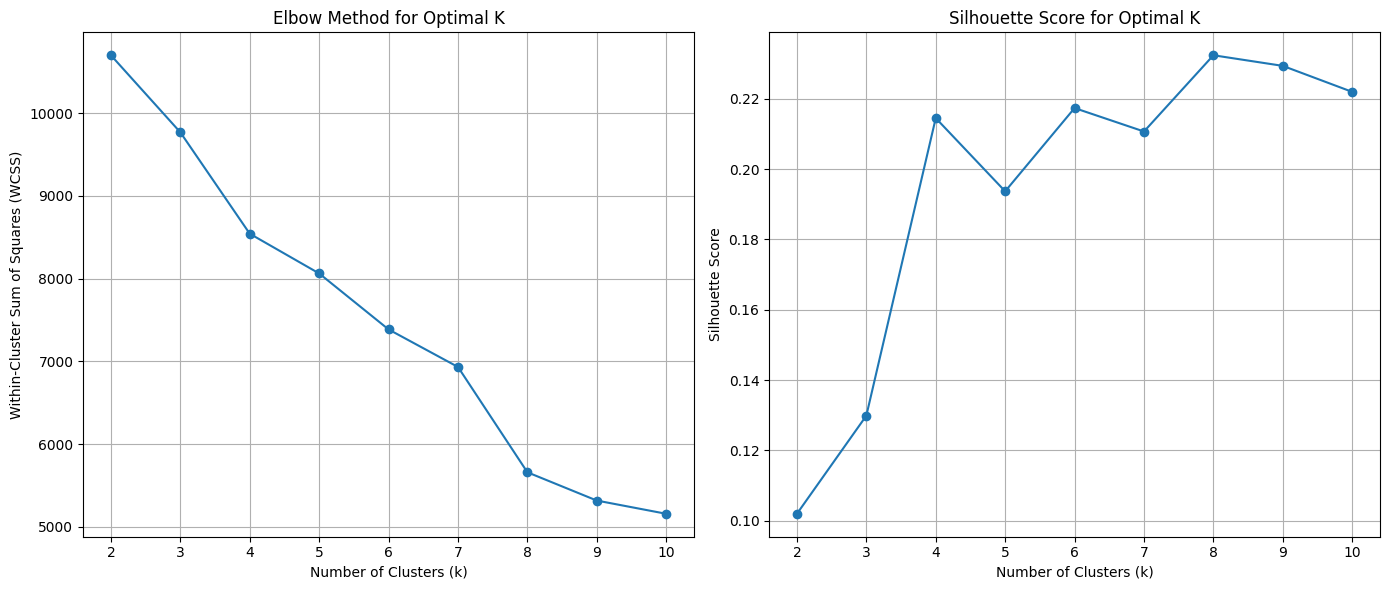

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Initialize lists to store WCSS and Silhouette Scores
wcss = []
silhouette_scores = []

# Define a range of cluster numbers to test
k_range = range(2, 11) # Testing from 2 to 10 clusters

# 2. Iterate through the range of possible cluster numbers
for k in k_range:
    # Instantiate KMeans model with current k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Fit the KMeans model to the scaled data
    kmeans.fit(X_scaled_clustering)

    # Append WCSS (inertia) to the list
    wcss.append(kmeans.inertia_)

    # Calculate and append Silhouette Score to the list
    # Silhouette score is only defined if number of labels is greater than 1
    if len(set(kmeans.labels_)) > 1:
        score = silhouette_score(X_scaled_clustering, kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(-1) # Append -1 or NaN if silhouette is not applicable


print("WCSS and Silhouette Scores calculated for different numbers of clusters.")

# 3. Plot the Elbow Method results
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(list(k_range))

# 4. Plot the Silhouette Score results
plt.subplot(1, 2, 2)
# Adjust k_range for silhouette scores if some k values resulted in single cluster
valid_k_range_silhouette = [k for k, score in zip(k_range, silhouette_scores) if score != -1]
valid_silhouette_scores = [score for score in silhouette_scores if score != -1]

plt.plot(valid_k_range_silhouette, valid_silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.xticks(list(valid_k_range_silhouette))

plt.tight_layout()
plt.show()

Optimal number of clusters (k) chosen: 4
KMeans model trained successfully.
Silhouette Score for K-Means with 4 clusters: 0.2145
Data reduced to 2D using PCA. Shape: (1000, 2)


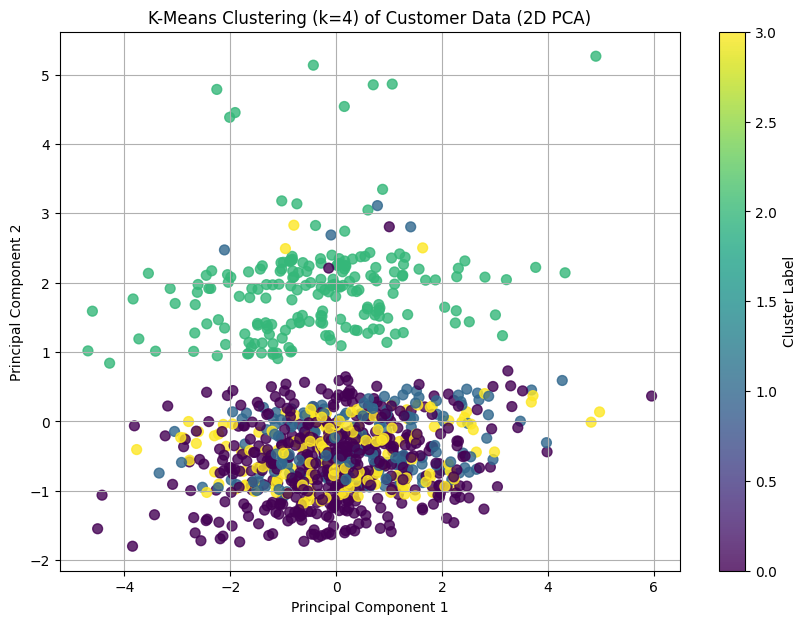

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Optimal number of clusters (k) determined from plots
k_optimal = 4 # Based on visual inspection of Elbow Method and Silhouette Score plots
print(f"Optimal number of clusters (k) chosen: {k_optimal}")

# 2. Instantiate KMeans model with the chosen optimal k
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')

# 3. Fit the KMeans model to the scaled data
kmeans_final.fit(X_scaled_clustering)

# 4. Get the cluster labels
cluster_labels = kmeans_final.labels_

print("KMeans model trained successfully.")

# 5. Calculate the Silhouette Score for the final clustering
silhouette_avg = silhouette_score(X_scaled_clustering, cluster_labels)
print(f"Silhouette Score for K-Means with {k_optimal} clusters: {silhouette_avg:.4f}")

# 6. Instantiate a PCA model with n_components=2
pca = PCA(n_components=2, random_state=42)

# 7. Fit and transform X_scaled_clustering using the PCA model
X_pca_final = pca.fit_transform(X_scaled_clustering)

print(f"Data reduced to 2D using PCA. Shape: {X_pca_final.shape}")

# 8. Create a scatter plot of X_pca_final, colored by cluster labels
plt.figure(figsize=(10, 7))
plt.scatter(X_pca_final[:, 0], X_pca_final[:, 1], c=cluster_labels, cmap='viridis', s=50, alpha=0.8)
plt.title(f'K-Means Clustering (k={k_optimal}) of Customer Data (2D PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

In [21]:
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

print("Cluster labels added to the DataFrame.")
print("First 5 rows of the clustered DataFrame:")
print(df_clustered.head())

Cluster labels added to the DataFrame.
First 5 rows of the clustered DataFrame:
   CustomerID  Age  Gender Location  Income  Frequency  MonetaryValue  \
0           1   56  Female  Houston   45361        8.0         681.60   
1           2   69    Male  Chicago   38717        6.0         471.94   
2           3   46    Male    Miami   54787        2.0          89.68   
3           4   32    Male  Phoenix   70106        5.0         430.68   
4           5   60    Male  Houston   21872        4.0         224.49   

   Recency  Cluster  
0     55.0        2  
1    165.0        0  
2    202.0        3  
3     22.0        1  
4    101.0        2  


In [22]:
print("Aggregated numerical statistics for each cluster:")
print(df_clustered.groupby('Cluster')[['Age', 'Income', 'Frequency', 'MonetaryValue', 'Recency']].mean())

print("\nCategorical feature distribution for each cluster:")
for col in ['Gender', 'Location']:
    print(f"\nDistribution for {col}:")
    print(df_clustered.groupby('Cluster')[col].value_counts(normalize=True).unstack(fill_value=0).round(2))


Aggregated numerical statistics for each cluster:
               Age        Income  Frequency  MonetaryValue     Recency
Cluster                                                               
0        44.422993  50706.600868   4.958785     379.807050  152.663774
1        42.934132  48841.479042   5.275449     405.738443  126.892216
2        41.489796  50836.352041   4.790816     364.211888  159.433673
3        45.670455  50151.352273   5.079545     397.722841  156.613636

Categorical feature distribution for each cluster:

Distribution for Gender:
Gender   Female  Male  Other
Cluster                     
0          0.50  0.50   0.00
1          0.46  0.52   0.02
2          0.53  0.40   0.07
3          0.53  0.45   0.02

Distribution for Location:
Location  Chicago  Houston  Los Angeles  Miami  New York  Phoenix
Cluster                                                          
0            0.32     0.00         0.33    0.0      0.35      0.0
1            0.00     0.00         0.00    0.0